<a href="https://colab.research.google.com/github/alxxx77/ciencia-de-dados-iesb-1-semestre/blob/main/Vacinacao_2026_feito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Dados de Vacinação no Brasil - 2026

## Introdução

Os dados utilizados neste trabalho foram coletados em junho de 2026. Como a base é atualizada continuamente, os resultados podem apresentar diferenças em consultas realizadas em datas posteriores. Portanto, as análises apresentadas refletem exclusivamente o conjunto de dados disponível no momento da coleta. Os dados contêm informações sobre doses aplicadas, características dos pacientes e dos estabelecimentos de saúde responsáveis pela vacinação.

A base contém registros de vacinação entre janeiro e Maio de 2026.

O conjunto de dados pode ser classificado como dados estruturados, pois as informações estão organizadas em linhas e colunas, facilitando sua manipulação e análise utilizando ferramentas como Python e Pandas.

A escolha desse tema foi motivada pela relevância da vacinação para a saúde pública. Além disso, trata-se de um assunto que impacta diretamente a população e permite explorar diferentes tipos de análises, como distribuição por gênero, faixa etária, raça/cor, estado e categoria de atendimento.

O principal objetivo deste trabalho é aplicar conceitos introdutórios de Ciência de Dados para coletar, organizar, tratar e analisar informações reais, extraindo indicadores que possam auxiliar na compreensão do cenário de vacinação registrado na base de dados utilizada.

Durante a análise serão utilizadas bibliotecas da linguagem Python para manipulação dos dados, geração de tabelas e construção de gráficos que permitam visualizar os resultados de forma mais clara.


## Coleta dos Dados

Os dados foram obtidos por meio de uma API pública disponibilizada pelo Ministério da Saúde. A utilização de uma API permite acessar informações atualizadas de forma automatizada, sem a necessidade de download manual de arquivos.

Nesta etapa, foi realizada a coleta dos registros de vacinação e o armazenamento das informações em um DataFrame do Pandas para posterior análise.


In [1]:
import requests
import pandas as pd
import time

url = "https://apidadosabertos.saude.gov.br/vacinacao/doses-aplicadas-pni-2026"

limite = 1000
total_paginas = 25

dados = []

for pagina in range(total_paginas):

    offset = pagina * limite

    parametros = {
        "limit": limite,
        "offset": offset
    }

    resposta = requests.get(url, params=parametros, timeout=120)

    dados_api = resposta.json()

    registros = dados_api.get("doses_aplicadas_pni", [])

    if len(registros) == 0:
        break

    for item in registros:
        dados.append(item)

    time.sleep(1)

df = pd.DataFrame(dados)

print("Total de registros:", len(df))


Total de registros: 25000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 56 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   descricao_natureza_estabelecimento      25000 non-null  object
 1   codigo_via_administracao                25000 non-null  object
 2   nome_pais_paciente                      24549 non-null  object
 3   codigo_origem_registro                  2075 non-null   object
 4   codigo_pais_paciente                    24549 non-null  object
 5   nome_raca_cor_paciente                  25000 non-null  object
 6   sigla_vacina                            25000 non-null  object
 7   codigo_vacina_fabricante                24442 non-null  object
 8   data_vacina                             25000 non-null  object
 9   codigo_condicao_maternal                24511 non-null  object
 10  nome_razao_social_estabelecimento       25000 non-null  object
 11  si

1 -Quantidade de pacientes distintos que vacinaram agrupados por categoria de atendimento;

Este tópico apresenta a quantidade de pacientes distintos vacinados agrupados por estado, permitindo visualizar a distribuição da vacinação entre as unidades federativas do país. A análise possibilita identificar os estados com maior número de pessoas imunizadas, contribuindo para a avaliação da cobertura vacinal e para o planejamento de estratégias de saúde pública em diferentes regiões.

In [4]:
#1 Pacientes por categoria de atendimento

resultado = df.groupby(
    "descricao_vacina_categoria_atendimento"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["categoria", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

print(resultado)

print("Total de categorias:", len(resultado))
print("Total de pacientes:", df["codigo_paciente"].nunique())


                                          categoria  qtd_pacientes
1                                      Faixa Etária          20843
5                                         Gestantes           1629
16                           Trabalhadores de Saúde            902
0                                      Comorbidades            351
10                                  Povos Indígenas            142
11                 Povos e Comunidades Tradicionais             21
8                    População Privada de Liberdade             20
12                                        Puérperas             18
6                                            Outros             12
15                        Trabalhadores da Educação              9
9                                   População Rural              5
13                        Trabalhadores Industriais              3
7                       Pessoas Institucionalizadas              2
3                  Forças de Segurança e Salvamento           

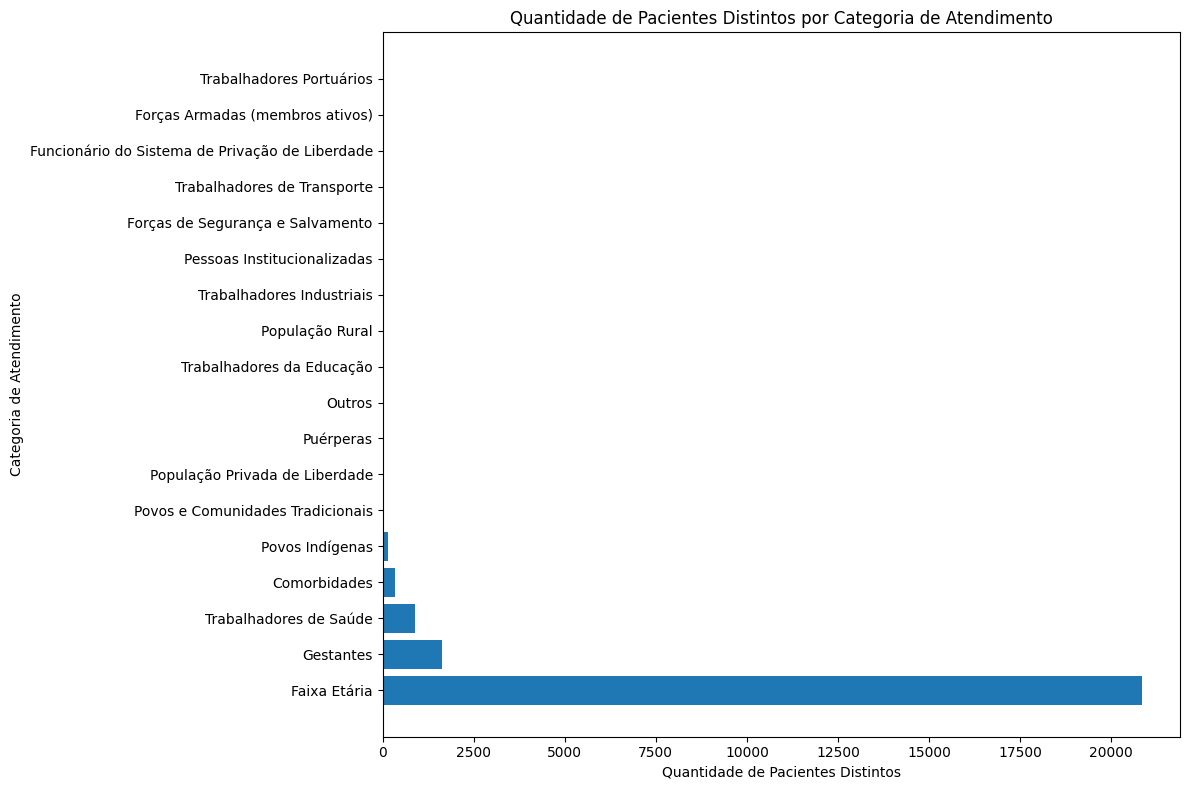

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.barh(
    resultado['categoria'],
    resultado['qtd_pacientes']
)

plt.title('Quantidade de Pacientes Distintos por Categoria de Atendimento')
plt.xlabel('Quantidade de Pacientes Distintos')
plt.ylabel('Categoria de Atendimento')

plt.tight_layout()
plt.show()

2 - Quantidade de pacientes distintos que vacinaram agrupado por Estado;
 Este tópico apresenta a distribuição das vacinas aplicadas entre os estados brasileiros, permitindo identificar regiões com maior cobertura vacinal. A análise auxilia na compreensão de desigualdades regionais e na avaliação da eficiência das campanhas de imunização.

In [6]:
#2 Pacientes por estado

resultado = df.groupby(
    "nome_uf_estabelecimento"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["estado", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

print(resultado)


                 estado  qtd_pacientes
24            SAO PAULO           5309
12         MINAS GERAIS           2240
4                 BAHIA           1439
18       RIO DE JANEIRO           1416
15               PARANA           1287
5                 CEARA           1114
16           PERNAMBUCO           1102
13                 PARA           1076
20    RIO GRANDE DO SUL           1076
23       SANTA CATARINA           1063
8                 GOIAS           1029
9              MARANHAO            929
3              AMAZONAS            845
11   MATO GROSSO DO SUL            592
10          MATO GROSSO            585
7        ESPIRITO SANTO            503
14              PARAIBA            448
17                PIAUI            438
1               ALAGOAS            436
6      DISTRITO FEDERAL            384
19  RIO GRANDE DO NORTE            362
26            TOCANTINS            305
25              SERGIPE            293
21             RONDONIA            260
0                  ACRE  

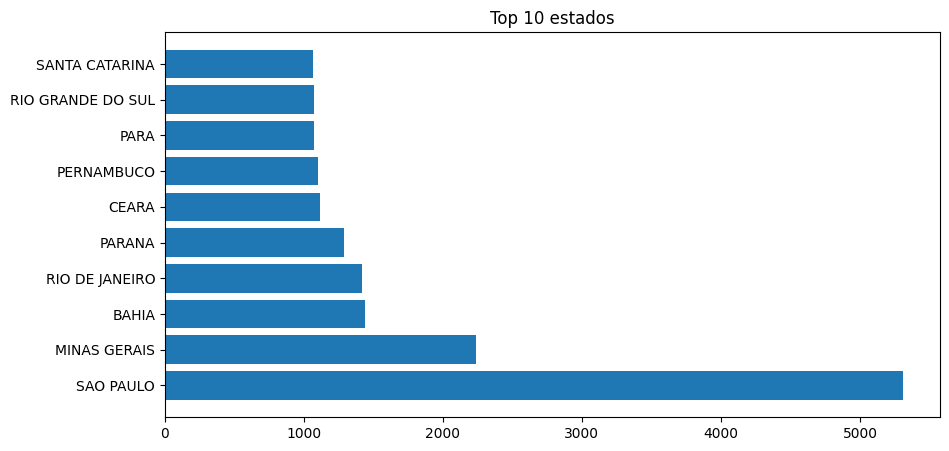

In [7]:
import matplotlib.pyplot as plt

resultado = df.groupby(
    "nome_uf_estabelecimento"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["estado", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

top10 = resultado.head(10)

plt.figure(figsize=(10,5))
plt.barh(top10["estado"], top10["qtd_pacientes"])
plt.title("Top 10 estados")
plt.show()


3 - Quantidade de pacientes distintos que vacinaram agrupados por raça e cor;
🧑🏾‍🤝‍🧑🏻 Doses por Raça/Cor

Este gráfico mostra a distribuição das doses aplicadas por raça/cor, com predominância nas categorias parda e branca.

         raca_cor  qtd_pacientes
3           PARDA          10176
1          BRANCA           7600
5  SEM INFORMACAO           5343
0         AMARELA           1134
4           PRETA            564
2        INDIGENA            118


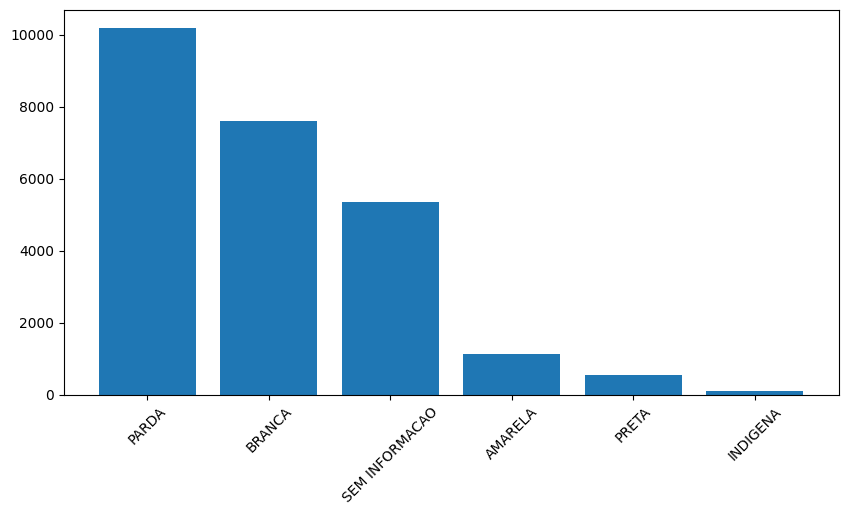

In [8]:
#3 pacientes agrupados por raça e cor

import matplotlib.pyplot as plt

resultado = df.groupby(
    "nome_raca_cor_paciente"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["raca_cor", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

print(resultado)

plt.figure(figsize=(10,5))
plt.bar(resultado["raca_cor"], resultado["qtd_pacientes"])
plt.xticks(rotation=45)
plt.show()


4- Quantidade de pacientes dististos agrupados por faixa etaria;

A distribuição de pacientes distintos por faixa etária permite identificar quais grupos populacionais foram mais alcançados pela vacinação. Essa análise evidencia padrões importantes, como maior cobertura em públicos prioritários ou maior adesão em determinadas idades, contribuindo para a avaliação da efetividade das estratégias de imunização ao longo do período analisado.

   faixa  qtd_pacientes
0    0-9           9889
1  10-19           2923
2  20-29           2057
3  30-39           1748
4  40-49            818
5  50-59            431
6  60-69            159
7  70-79             57
8  80-89             15
9    90+              3


/tmp/ipykernel_8291/3829580134.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resultado = df.groupby("faixa_etaria")["codigo_paciente"].nunique()


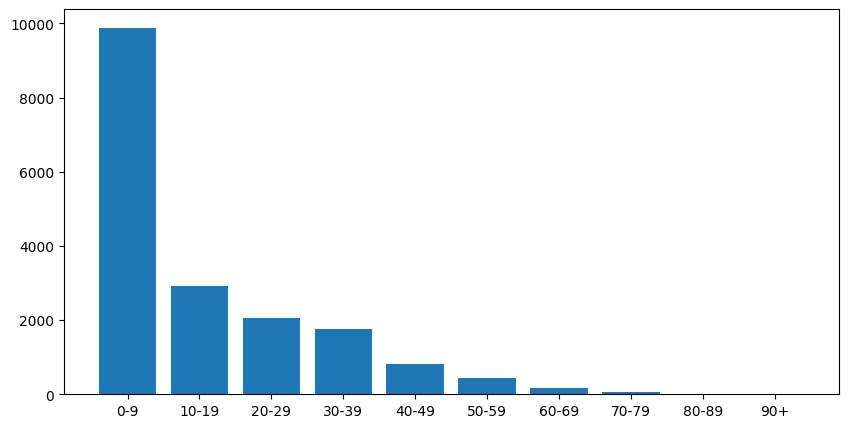

In [9]:
#4 pacientes agrupados por faixa etaria

import pandas as pd
import matplotlib.pyplot as plt

df["idade"] = pd.to_numeric(
    df["numero_idade_paciente"],
    errors="coerce"
)

bins = [0,9,19,29,39,49,59,69,79,89,200]
labels = ["0-9","10-19","20-29","30-39","40-49","50-59","60-69","70-79","80-89","90+"]

df["faixa_etaria"] = pd.cut(
    df["idade"],
    bins=bins,
    labels=labels
)

resultado = df.groupby("faixa_etaria")["codigo_paciente"].nunique()
resultado = resultado.reset_index()
resultado.columns = ["faixa", "qtd_pacientes"]

print(resultado)

plt.figure(figsize=(10,5))
plt.bar(resultado["faixa"], resultado["qtd_pacientes"])
plt.show()


5- Descrição do tipo de vacina;

Neste gráfico é possível observar que a vacina Pfizer (Comirnaty) foi a mais aplicada no período analisado, seguida por AstraZeneca e CoronaVac. Também aparecem versões específicas como vacinas pediátricas e bivalentes, indicando diversidade de imunizantes utilizados na campanha.

In [10]:
#5 - descricao_vacina

resultado = df.groupby(
    "descricao_vacina"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["vacina", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

print(resultado)


                              vacina  qtd_pacientes
6                   Vacina pneumo 10           6773
10  Vacina sarampo, caxumba, rubéola           5485
1           Vacina HPV quadrivalente           5325
2                 Vacina dTpa adulto           3313
3         Vacina hepatite A infantil           2954
5                Vacina meningo ACWY            567
0                    Vacina DTPa/VIP            220
7                   Vacina pneumo 13            215
9      Vacina rotavírus pentavalente            105
11                   Vacina varicela             10
4        Vacina influenza trivalente              8
8             Vacina polio injetável              2


6- Quantidade de doses por pacientes distintos;

A análise da quantidade de doses em relação ao número de pacientes distintos permite avaliar o alcance real da vacinação na população. Enquanto o total de doses indica o volume de aplicações realizadas, o número de indivíduos únicos mostra quantas pessoas foram efetivamente atendidas. A diferença entre esses valores reflete a aplicação de esquemas vacinais completos, incluindo doses adicionais e de reforço, sendo um indicador importante da continuidade e efetividade da imunização.

In [11]:
#6 - descricao_dose_vacina

resultado = df.groupby(
    "descricao_dose_vacina"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["dose", "qtd_pacientes"]

resultado = resultado.sort_values(
    "qtd_pacientes",
    ascending=False
)

print(resultado)


                   dose  qtd_pacientes
0               1ª Dose           9384
15                Única           8227
10                 Dose           2487
2               2ª Dose           2277
13              Reforço           1975
5               3ª Dose            266
1            1º Reforço            185
4            2º Reforço             77
12            Dose Zero             73
9            5º Reforço              9
6            3º Reforço              7
8            4º Reforço              7
11       Dose Adicional              2
7               4ª Dose              2
3   2ª Dose Revacinação              1
14          Revacinação              1


7- Gêneros dos pacientes;

A análise dos gêneros dos pacientes permite compreender a distribuição da vacinação entre os diferentes grupos, evidenciando possíveis diferenças no acesso ou na adesão à imunização. Essa informação é relevante para identificar padrões populacionais e apoiar estratégias mais inclusivas e equitativas nas campanhas de vacinação.

  genero  qtd_pacientes
0      F          13413
1      M          11522


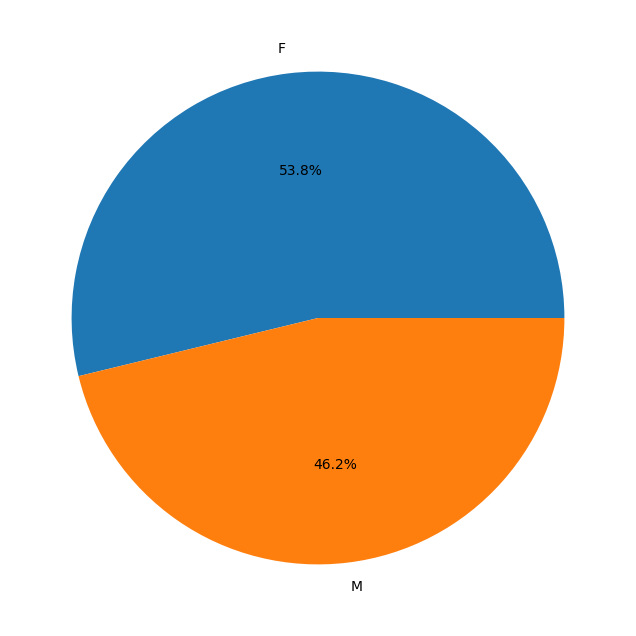

In [12]:
#7 - tipo_genero_paciente

import matplotlib.pyplot as plt

resultado = df.groupby(
    "tipo_sexo_paciente"
)["codigo_paciente"].nunique()

resultado = resultado.reset_index()
resultado.columns = ["genero", "qtd_pacientes"]

print(resultado)

plt.figure(figsize=(8,8))
plt.pie(
    resultado["qtd_pacientes"],
    labels=resultado["genero"],
    autopct="%1.1f%%"
)
plt.show()

8- Tipo de estabelecimento;


“Tipo de estabelecimento” é uma classificação usada para identificar a natureza ou atividade principal de um local ou empresa.

In [13]:
#8 descricao_tipo_estabelecimento

resultado = df.groupby(
    "descricao_tipo_estabelecimento"
).size()

resultado = resultado.reset_index()
resultado.columns = ["tipo_estabelecimento", "quantidade"]

resultado = resultado.sort_values(
    "quantidade",
    ascending=False
)

print(resultado)


                                 tipo_estabelecimento  quantidade
5                      CENTRO DE SAUDE/UNIDADE BASICA       21658
15                                     POSTO DE SAUDE         581
6                     CLINICA/CENTRO DE ESPECIALIDADE         574
4                                CENTRO DE IMUNIZACAO         563
13                                        POLICLINICA         429
11                                     HOSPITAL GERAL         312
9                                            FARMACIA         147
18  UNIDADE DE APOIO DIAGNOSE E TERAPIA (SADT ISOL...         136
19                UNIDADE DE ATENCAO A SAUDE INDIGENA         126
7                                 CONSULTORIO ISOLADO          78
10                             HOSPITAL ESPECIALIZADO          66
1                          CENTRAL DE GESTAO EM SAUDE          59
0                            CENTRAL DE ABASTECIMENTO          57
21                                      UNIDADE MISTA          43
20        